In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Geometry / trajectory parsing
from shapely import wkb
from shapely.geometry import LineString, Point

# ML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Optional: XGBoost / LightGBM (use whichever is available)
try:
    import lightgbm as lgb
    HAS_LGB = True
    print('LightGBM available ✓')
except ImportError:
    HAS_LGB = False
    print('LightGBM not found — using RandomForest as fallback')

# Style
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

# Paths — adjust if needed
DATA_DIR = Path('dataset')   # place CSVs next to this notebook
TRAIN_PATH = DATA_DIR / 'train_data.csv'
TEST_PATH  = DATA_DIR / 'test_data.csv'

CLASSES = ['Clutter','Cormorants','Pigeons','Ducks','Geese','Gulls','Birds of Prey','Waders','Songbirds']
print('Setup complete.')

LightGBM available ✓
Setup complete.


In [4]:
train = pd.read_csv("dataset/train.csv")
test  = pd.read_csv("dataset/test.csv")

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print()
print('Train columns:', train.columns.tolist())
print()
train.head(3)

Train shape : (2601, 16)
Test shape  : (1872, 9)

Train columns: ['track_id', 'timestamp_start_radar_utc', 'timestamp_end_radar_utc', 'trajectory', 'trajectory_time', 'radar_bird_size', 'airspeed', 'min_z', 'max_z', 'observation_id', 'primary_observation_id', 'observer_position', 'observer_comment', 'n_birds_observed', 'bird_group', 'bird_species']



,track_id,timestamp_start_radar_utc,timestamp_end_radar_utc,trajectory,trajectory_time,radar_bird_size,airspeed,min_z,max_z,observation_id,primary_observation_id,observer_position,observer_comment,n_birds_observed,bird_group,bird_species
0,2537685,2023-09-05 08:59:18,2023-09-05 09:00:52,01020000E0E61000005200000026EE676787321B403B57...,"[0.0, 1.01982, 2.03911, 3.05854, 4.07798, 5.09...",Small bird,16.3071,50.019,151.222,2214,2214,01010000A0E6100000509297E6A2381B407E2E588CE4BA...,NaN,1,Waders,Dunlin
1,2538937,2023-09-05 09:00:31,2023-09-05 09:02:25,01020000E0E6100000670000000364E067F9351B4030B8...,"[0.0, 1.01519, 2.02996, 4.06014, 5.07671, 7.10...",Small bird,10.7888,0.800,62.424,2215,2215,01010000A0E610000026926751A6301B40D0083ACC62BA...,NaN,1,Gulls,Black-headed Gull
2,2539560,2023-09-05 09:01:13,2023-09-05 09:03:36,01020000E0E61000007D00000040B7E1C160401B4045EC...,"[0.0, 2.02202, 3.03262, 4.04231, 5.05144, 6.06...",Small bird,11.5862,-1.683,29.396,2216,2216,01010000A0E6100000123E455C15391B40F5A1FA8181BA...,NaN,1,Gulls,European Herring Gull


In [5]:
# Parse timestamps
for df in [train, test]:
    df['ts_start'] = pd.to_datetime(df['timestamp_start_radar_utc'], utc=True)
    df['ts_end']   = pd.to_datetime(df['timestamp_end_radar_utc'],   utc=True)
    df['duration_s'] = (df['ts_end'] - df['ts_start']).dt.total_seconds()

print('Timestamps parsed.')
train[['ts_start','ts_end','duration_s']].describe()

Timestamps parsed.


,duration_s
count,2601.000000
mean,61.193003
std,48.627466
min,7.000000
25%,25.000000
50%,48.000000
75%,82.000000
max,544.000000


In [6]:
def parse_trajectory(hex_str):
    """
    Decode EWKB hex string into a list of (lon, lat, alt, rcs) tuples.
    Returns empty list on failure.
    """
    if not isinstance(hex_str, str) or len(hex_str) == 0:
        return []
    try:
        geom = wkb.loads(hex_str, hex=True)
        if geom.geom_type == 'LineString':
            coords = list(geom.coords)  # each coord: (lon, lat, alt, rcs) if 4D
            return coords
        elif geom.geom_type == 'Point':
            return [geom.coords[0]]
        elif geom.geom_type in ('MultiPoint', 'GeometryCollection'):
            return [g.coords[0] for g in geom.geoms]
    except Exception:
        pass
    return []

# Test on one row
sample = parse_trajectory(train['trajectory'].iloc[0])
print(f'Sample trajectory has {len(sample)} points.')
if sample:
    print(f'First point (lon, lat, alt, rcs): {sample[0]}')

Sample trajectory has 82 points.
First point (lon, lat, alt, rcs): (6.79934465, 53.45849494, 51.576, -32.3)


In [7]:
def trajectory_features(row):
    """Extract numeric features from a trajectory."""
    coords = parse_trajectory(row['trajectory'])
    times  = row.get('trajectory_time', '')

    # Parse time list
    t_list = []
    if isinstance(times, str) and times.strip():
        try:
            t_list = [float(x) for x in times.strip('[]').split(',')]
        except:
            pass
    elif isinstance(times, (list, np.ndarray)):
        t_list = list(times)

    n = len(coords)
    if n == 0:
        return {}

    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    alts = [c[2] for c in coords] if len(coords[0]) > 2 else [np.nan]*n
    rcs  = [c[3] for c in coords] if len(coords[0]) > 3 else [np.nan]*n

    # Approximate horizontal displacement (degrees → rough meters at ~53°N)
    dx = np.diff(lons) * 71000   # ~71 km/deg lon at 53°N
    dy = np.diff(lats) * 111000  # ~111 km/deg lat
    step_dist = np.sqrt(dx**2 + dy**2)

    total_dist = step_dist.sum() if len(step_dist) > 0 else 0.0

    # Bearing changes (tortuosity)
    bearings = np.arctan2(dy, dx)
    bearing_changes = np.abs(np.diff(bearings)) if len(bearings) > 1 else np.array([0.0])
    bearing_changes = np.minimum(bearing_changes, 2*np.pi - bearing_changes)  # wrap

    return {
        'n_points'           : n,
        'total_dist_m'       : total_dist,
        'mean_step_m'        : step_dist.mean() if len(step_dist) > 0 else 0.0,
        'std_step_m'         : step_dist.std()  if len(step_dist) > 0 else 0.0,
        'lon_range'          : max(lons) - min(lons),
        'lat_range'          : max(lats) - min(lats),
        'alt_mean'           : np.nanmean(alts),
        'alt_std'            : np.nanstd(alts),
        'rcs_mean'           : np.nanmean(rcs),
        'rcs_std'            : np.nanstd(rcs),
        'rcs_min'            : np.nanmin(rcs),
        'rcs_max'            : np.nanmax(rcs),
        'tortuosity'         : bearing_changes.mean() if len(bearing_changes) > 0 else 0.0,
        'tortuosity_max'     : bearing_changes.max() if len(bearing_changes) > 0 else 0.0,
    }

print('Computing trajectory features for train set (this may take a moment)...')
traj_feats_train = train.apply(trajectory_features, axis=1)
traj_df_train = pd.DataFrame(list(traj_feats_train))

print('Computing trajectory features for test set...')
traj_feats_test = test.apply(trajectory_features, axis=1)
traj_df_test = pd.DataFrame(list(traj_feats_test))

print(f'Trajectory feature matrix: {traj_df_train.shape}')
traj_df_train.head(3)

Computing trajectory features for train set (this may take a moment)...


Computing trajectory features for test set...
Trajectory feature matrix: (2601, 14)


,n_points,total_dist_m,mean_step_m,std_step_m,lon_range,lat_range,alt_mean,alt_std,rcs_mean,rcs_std,rcs_min,rcs_max,tortuosity,tortuosity_max
0,82,1286.636800,15.884405,6.125837,0.016175,0.003602,106.459512,29.339440,-31.648780,4.592126,-39.7,-21.4,0.195771,1.166415
1,103,1137.249135,11.149501,4.924999,0.008253,0.007996,33.175097,17.790898,-30.642718,3.525899,-40.0,-23.0,0.243798,2.658516
2,125,1868.886921,15.071669,5.864184,0.016813,0.011690,10.595808,10.451162,-27.439200,5.363400,-39.7,-6.1,0.187217,1.270498


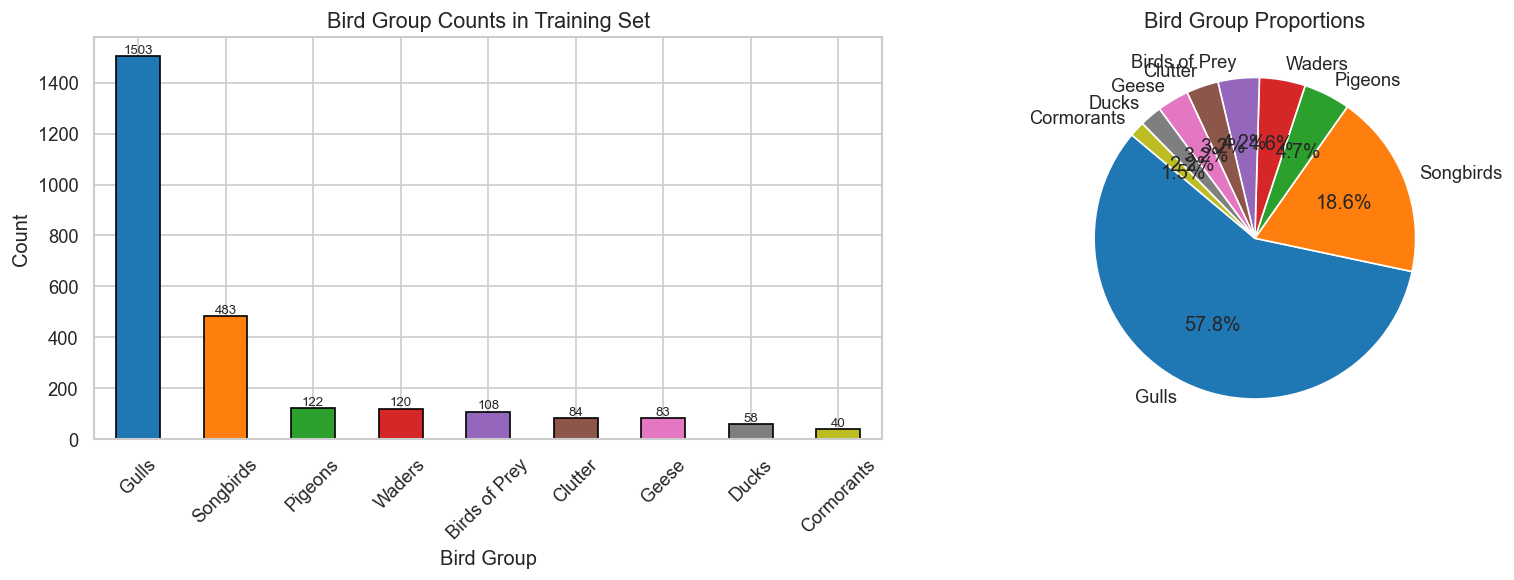

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = train['bird_group'].value_counts()

# Bar chart
counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('tab10', len(counts)), edgecolor='black')
axes[0].set_title('Bird Group Counts in Training Set', fontsize=13)
axes[0].set_xlabel('Bird Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('tab10', len(counts)), startangle=140)
axes[1].set_title('Bird Group Proportions', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

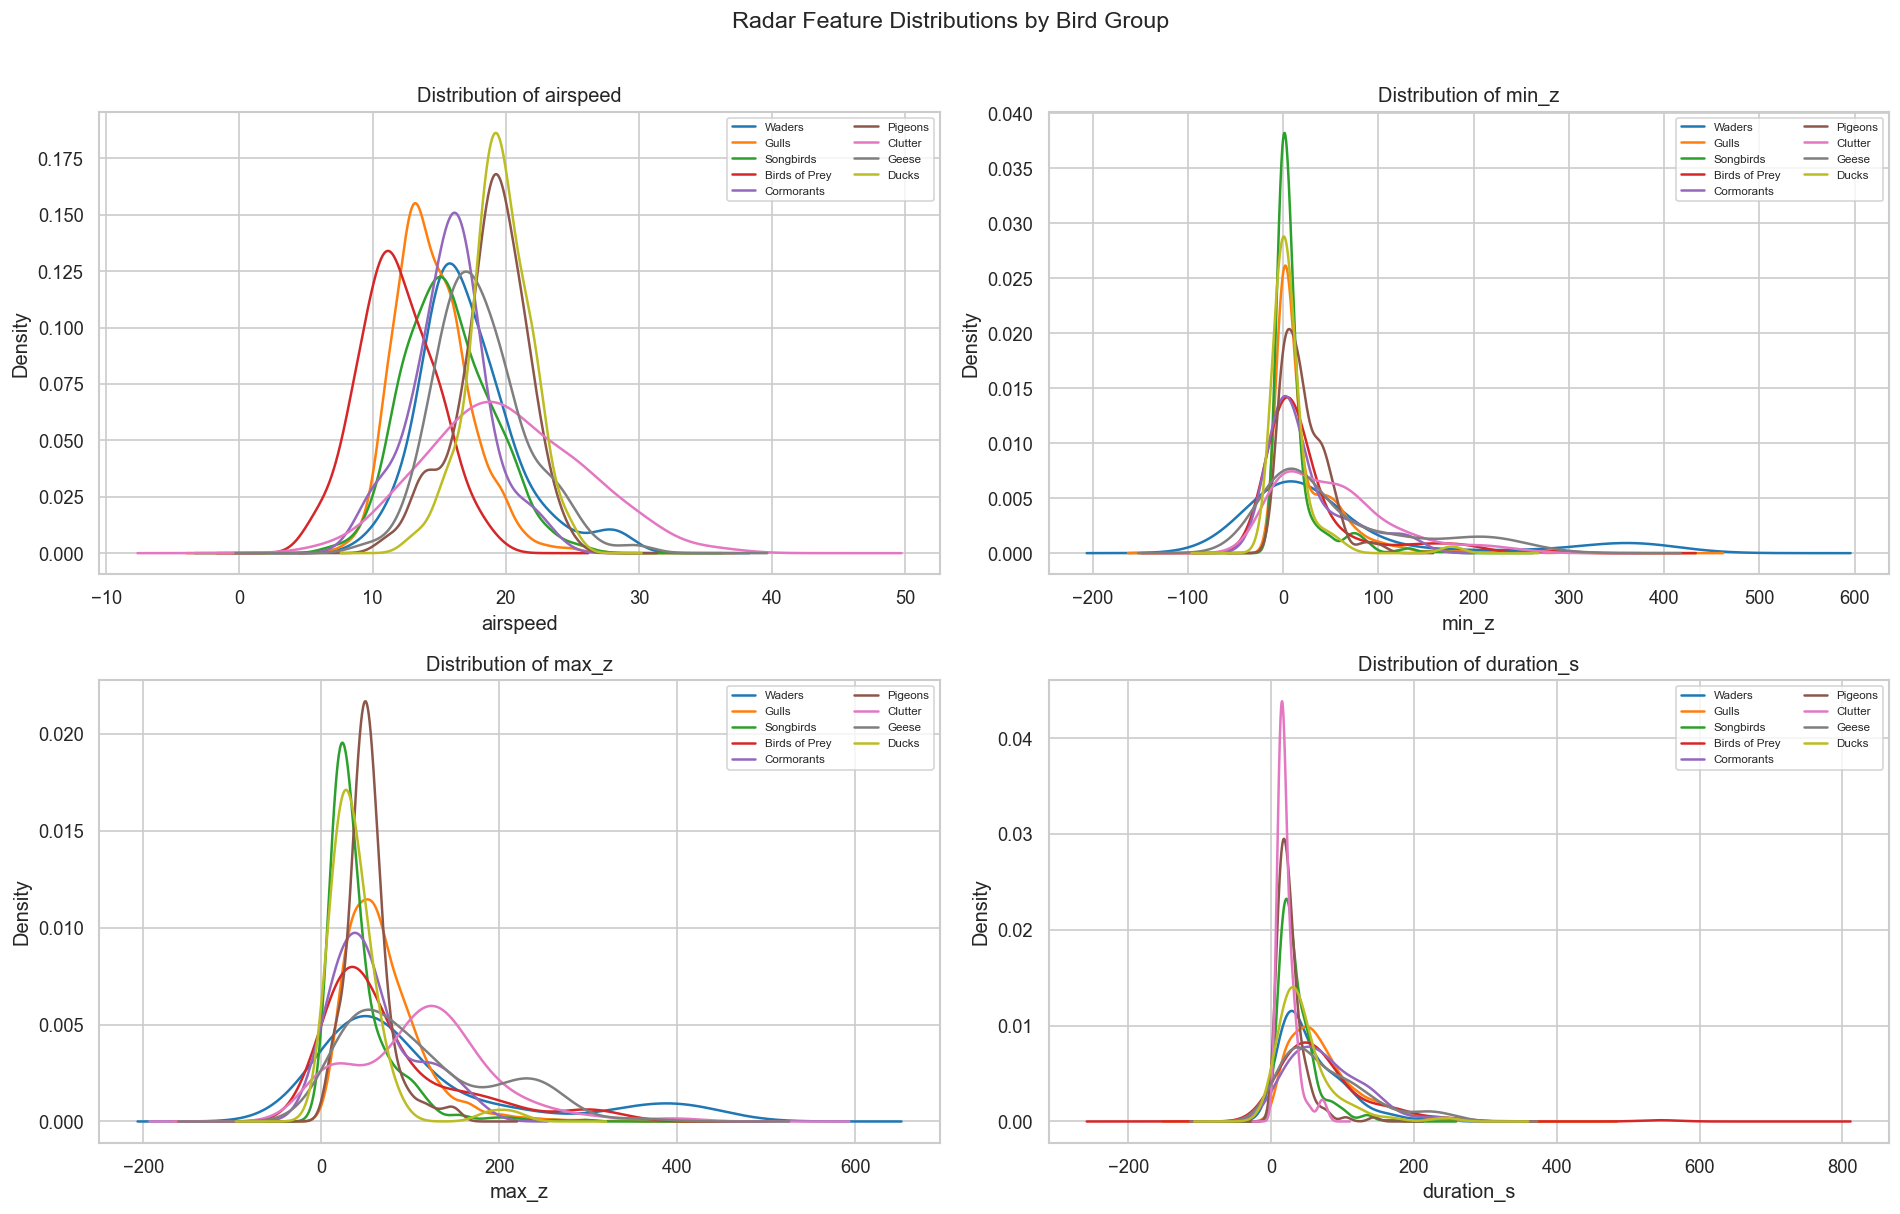

In [9]:
radar_cols = ['airspeed', 'min_z', 'max_z', 'duration_s']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(radar_cols):
    if col in train.columns:
        for group in train['bird_group'].unique():
            vals = train.loc[train['bird_group'] == group, col].dropna()
            if len(vals) > 5:
                vals.plot.kde(ax=axes[i], label=group, linewidth=1.5)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].legend(fontsize=7, ncol=2)
        axes[i].set_xlim(left=None)

plt.suptitle('Radar Feature Distributions by Bird Group', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

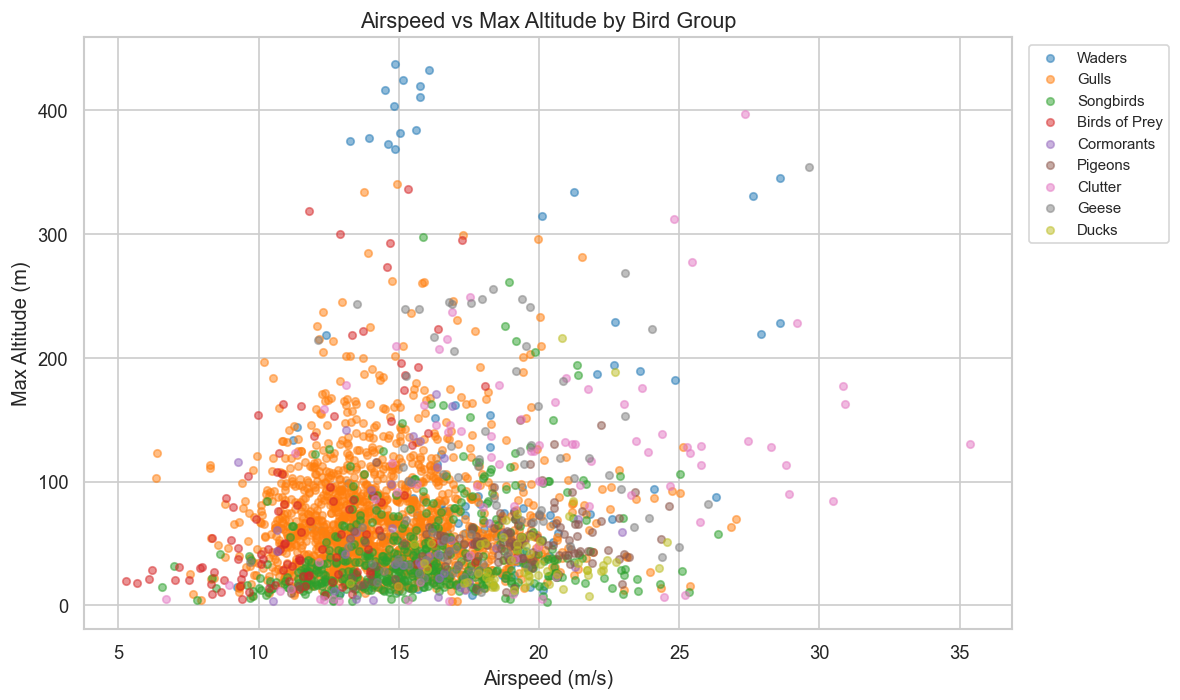

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('tab10', train['bird_group'].nunique())

for i, group in enumerate(train['bird_group'].unique()):
    subset = train[train['bird_group'] == group]
    ax.scatter(
        subset['airspeed'], subset['max_z'],
        alpha=0.5, s=20, label=group, color=palette[i]
    )

ax.set_xlabel('Airspeed (m/s)', fontsize=12)
ax.set_ylabel('Max Altitude (m)', fontsize=12)
ax.set_title('Airspeed vs Max Altitude by Bird Group', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('scatter_airspeed_altitude.png', bbox_inches='tight')
plt.show()

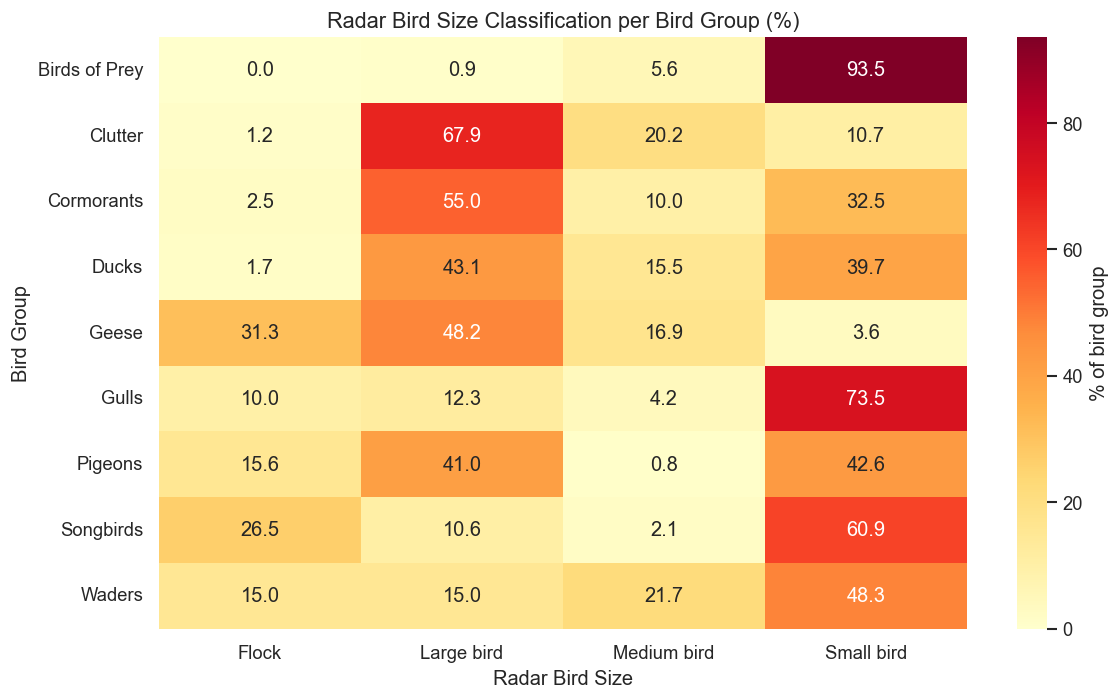

In [11]:
crosstab = pd.crosstab(train['bird_group'], train['radar_bird_size'])
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    crosstab_pct, annot=True, fmt='.1f', cmap='YlOrRd',
    cbar_kws={'label': '% of bird group'}, ax=ax
)
ax.set_title('Radar Bird Size Classification per Bird Group (%)', fontsize=13)
ax.set_xlabel('Radar Bird Size')
ax.set_ylabel('Bird Group')
plt.tight_layout()
plt.savefig('heatmap_radar_size.png', bbox_inches='tight')
plt.show()

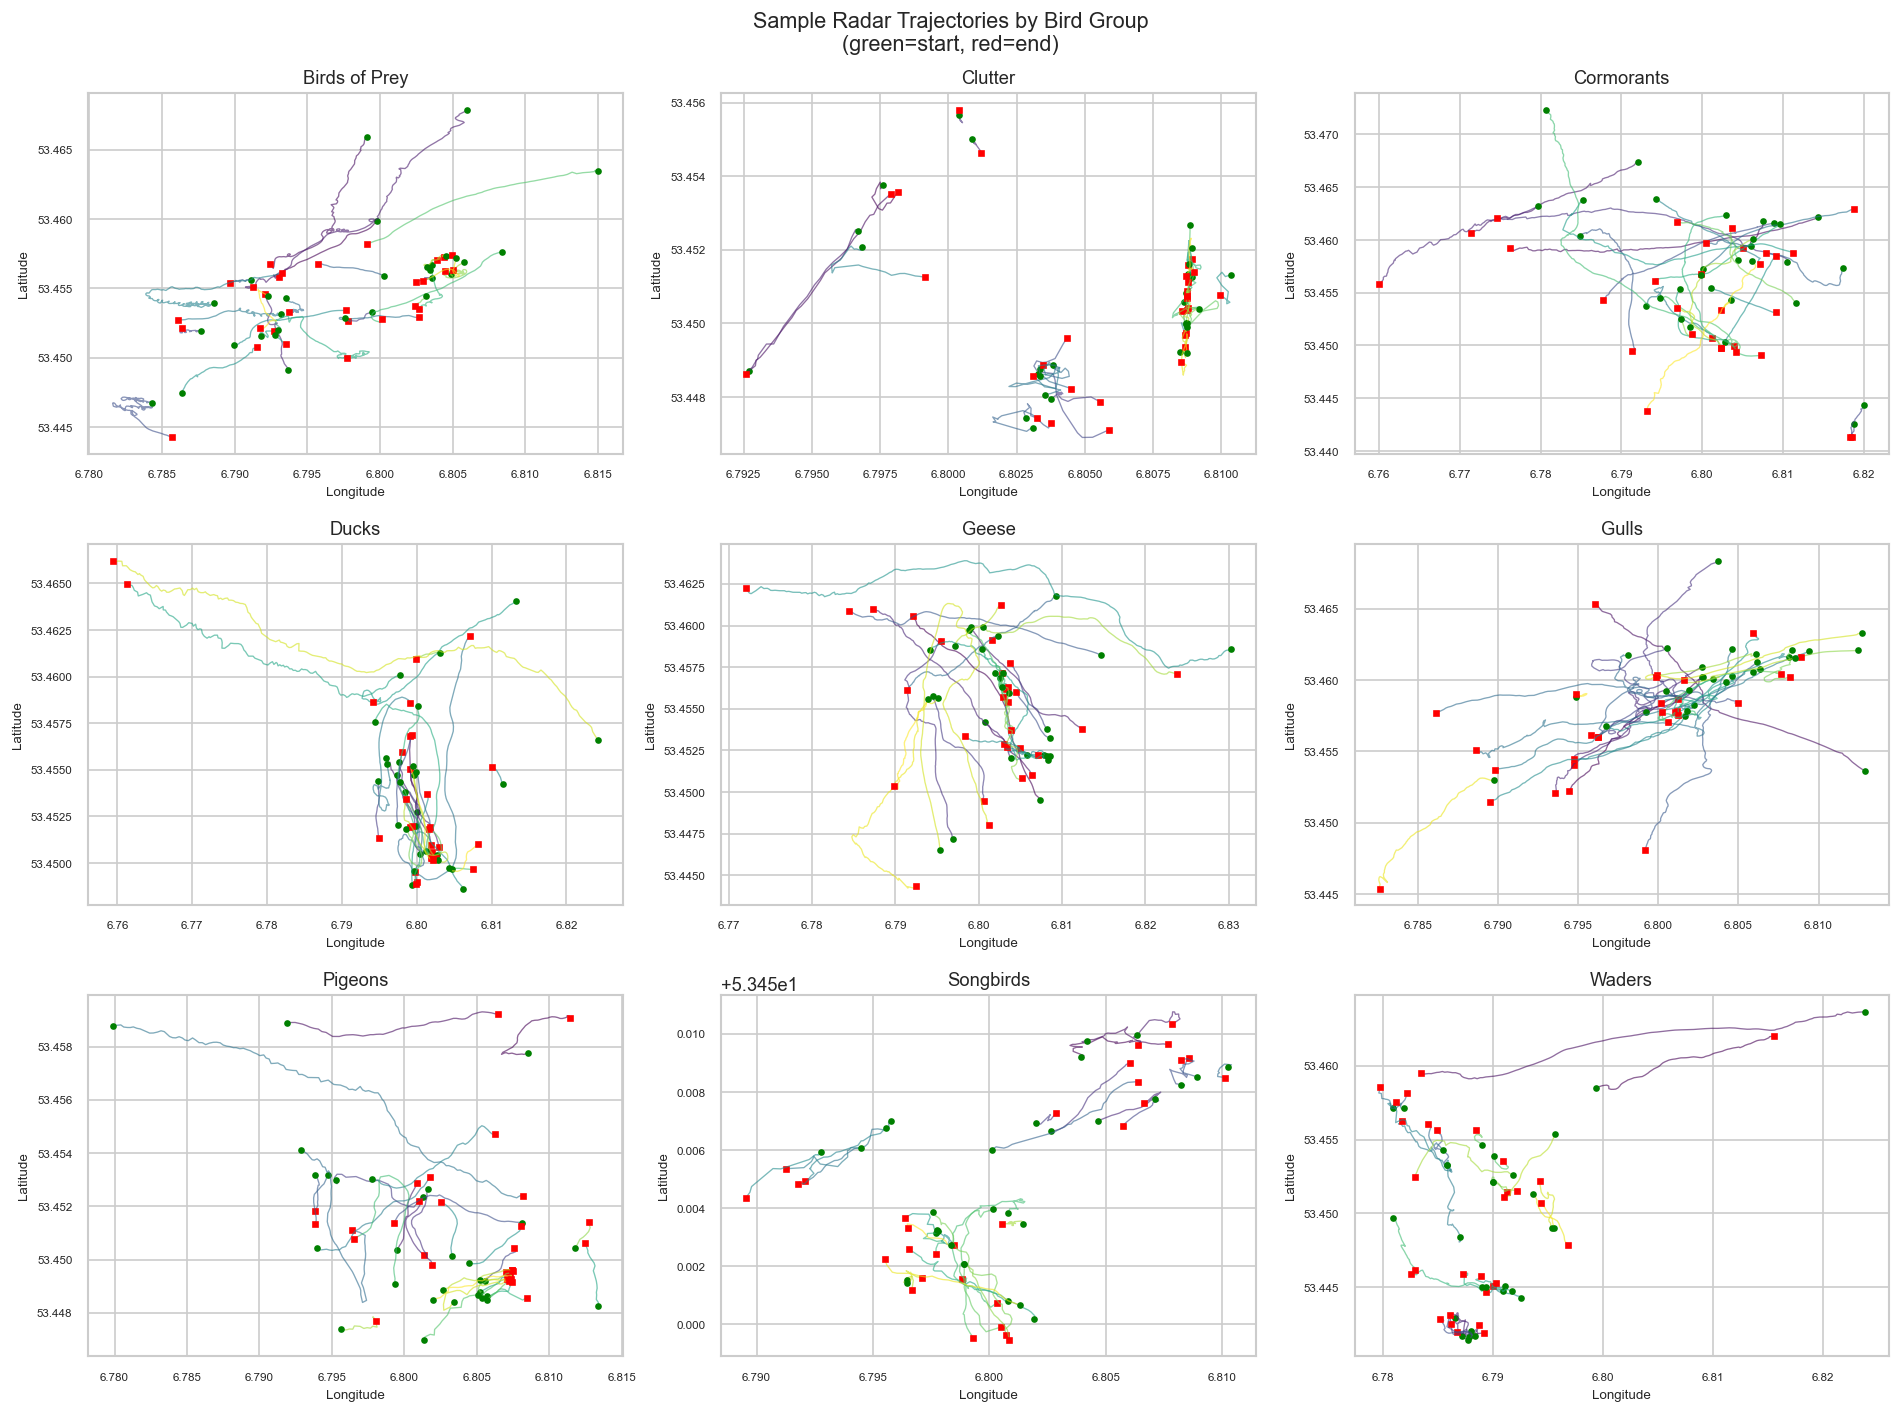

In [12]:
groups = train['bird_group'].unique()
n_groups = len(groups)
ncols = 3
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for idx, group in enumerate(sorted(groups)):
    ax = axes[idx]
    subset = train[train['bird_group'] == group].head(30)  # plot up to 30 tracks
    colors = cm.viridis(np.linspace(0, 1, len(subset)))
    for i, (_, row) in enumerate(subset.iterrows()):
        coords = parse_trajectory(row['trajectory'])
        if len(coords) >= 2:
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            ax.plot(lons, lats, alpha=0.6, linewidth=0.8, color=colors[i])
            ax.plot(lons[0], lats[0], 'go', markersize=3)  # start
            ax.plot(lons[-1], lats[-1], 'rs', markersize=3)  # end
    ax.set_title(group, fontsize=11)
    ax.set_xlabel('Longitude', fontsize=8)
    ax.set_ylabel('Latitude', fontsize=8)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sample Radar Trajectories by Bird Group\n(green=start, red=end)', fontsize=13)
plt.tight_layout()
plt.savefig('trajectory_maps.png', bbox_inches='tight')
plt.show()

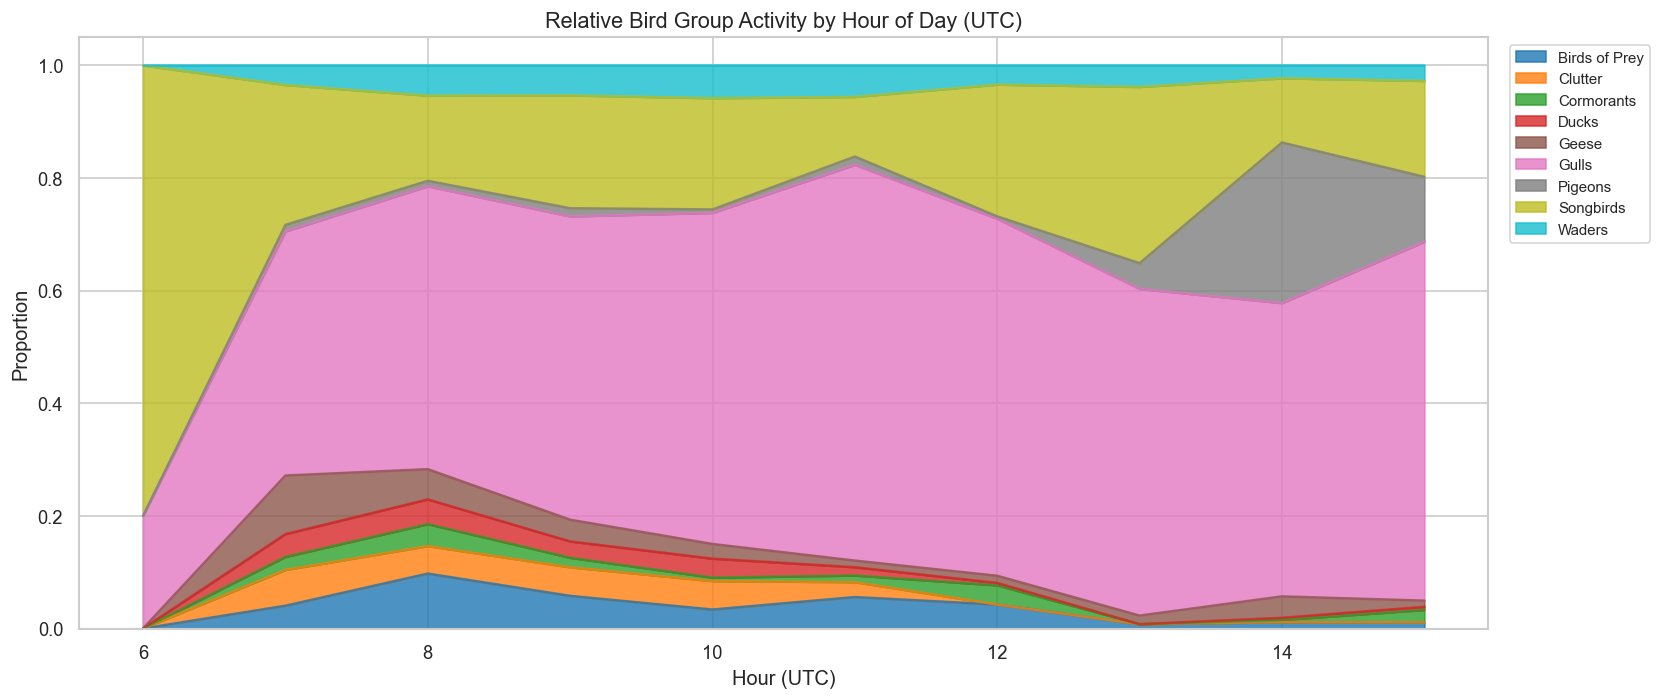

In [13]:
train['hour'] = train['ts_start'].dt.hour

fig, ax = plt.subplots(figsize=(14, 6))
hour_group = train.groupby(['hour', 'bird_group']).size().unstack(fill_value=0)
hour_group_pct = hour_group.div(hour_group.sum(axis=1), axis=0)
hour_group_pct.plot(kind='area', stacked=True, ax=ax, colormap='tab10', alpha=0.8)

ax.set_title('Relative Bird Group Activity by Hour of Day (UTC)', fontsize=13)
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Proportion')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('temporal_patterns.png', bbox_inches='tight')
plt.show()

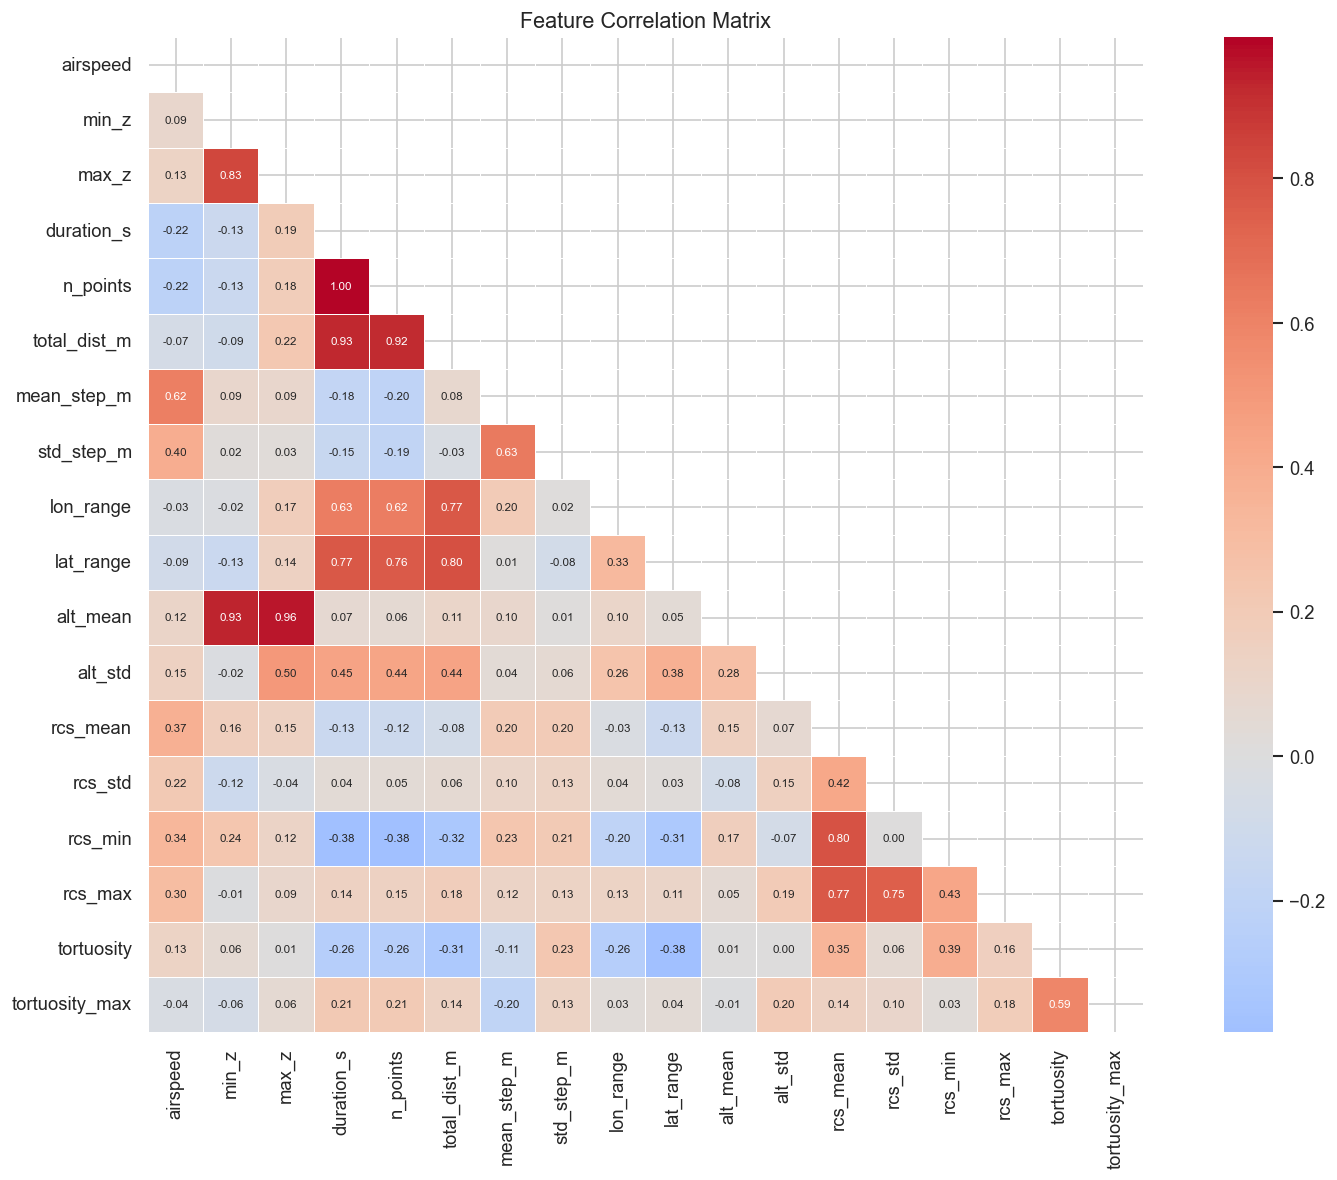

In [14]:
num_cols = ['airspeed', 'min_z', 'max_z', 'duration_s']
feat_corr = pd.concat([train[num_cols].reset_index(drop=True), traj_df_train], axis=1)
corr = feat_corr.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

In [15]:
def build_feature_matrix(df, traj_feats_df):
    feats = df[['airspeed', 'min_z', 'max_z', 'duration_s']].copy().reset_index(drop=True)

    # Radar size one-hot
    size_dummies = pd.get_dummies(df['radar_bird_size'], prefix='radar_size').reset_index(drop=True)
    feats = pd.concat([feats, size_dummies], axis=1)

    # Time features
    feats['hour']       = df['ts_start'].dt.hour.values
    feats['month']      = df['ts_start'].dt.month.values
    feats['is_daytime'] = ((feats['hour'] >= 6) & (feats['hour'] <= 20)).astype(int)

    # Derived radar features
    feats['alt_range']      = (df['max_z'] - df['min_z']).values
    feats['airspeed_per_m'] = (df['airspeed'] / (df['max_z'] + 1)).values

    # Trajectory features
    traj_feats_df = traj_feats_df.reset_index(drop=True)
    feats = pd.concat([feats, traj_feats_df], axis=1)

    return feats

X_train_raw = build_feature_matrix(train, traj_df_train)
X_test_raw  = build_feature_matrix(test,  traj_df_test)

# Align columns (test might be missing some one-hot columns)
X_train_raw, X_test_raw = X_train_raw.align(X_test_raw, join='left', axis=1, fill_value=0)

y_train = train['bird_group'].values

print(f'Feature matrix shape: {X_train_raw.shape}')
print(f'Features: {X_train_raw.columns.tolist()}')

Feature matrix shape: (2601, 27)
Features: ['airspeed', 'min_z', 'max_z', 'duration_s', 'radar_size_Flock', 'radar_size_Large bird', 'radar_size_Medium bird', 'radar_size_Small bird', 'hour', 'month', 'is_daytime', 'alt_range', 'airspeed_per_m', 'n_points', 'total_dist_m', 'mean_step_m', 'std_step_m', 'lon_range', 'lat_range', 'alt_mean', 'alt_std', 'rcs_mean', 'rcs_std', 'rcs_min', 'rcs_max', 'tortuosity', 'tortuosity_max']


Model Training & Evaluation

In [16]:
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train_raw)
X_test  = imputer.transform(X_test_raw)
print('Missing values imputed.')

Missing values imputed.


In [17]:
if HAS_LGB:
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
else:
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

print(f'Model: {type(model).__name__}')

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'\n5-Fold CV F1 (macro): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold scores: {np.round(cv_scores, 4)}')

Model: LGBMClassifier

5-Fold CV F1 (macro): 0.5879 ± 0.0125
Per-fold scores: [0.5731 0.575  0.6043 0.5992 0.588 ]


In [18]:
model.fit(X_train, y_train)
print('Model fitted on full training set.')

Model fitted on full training set.


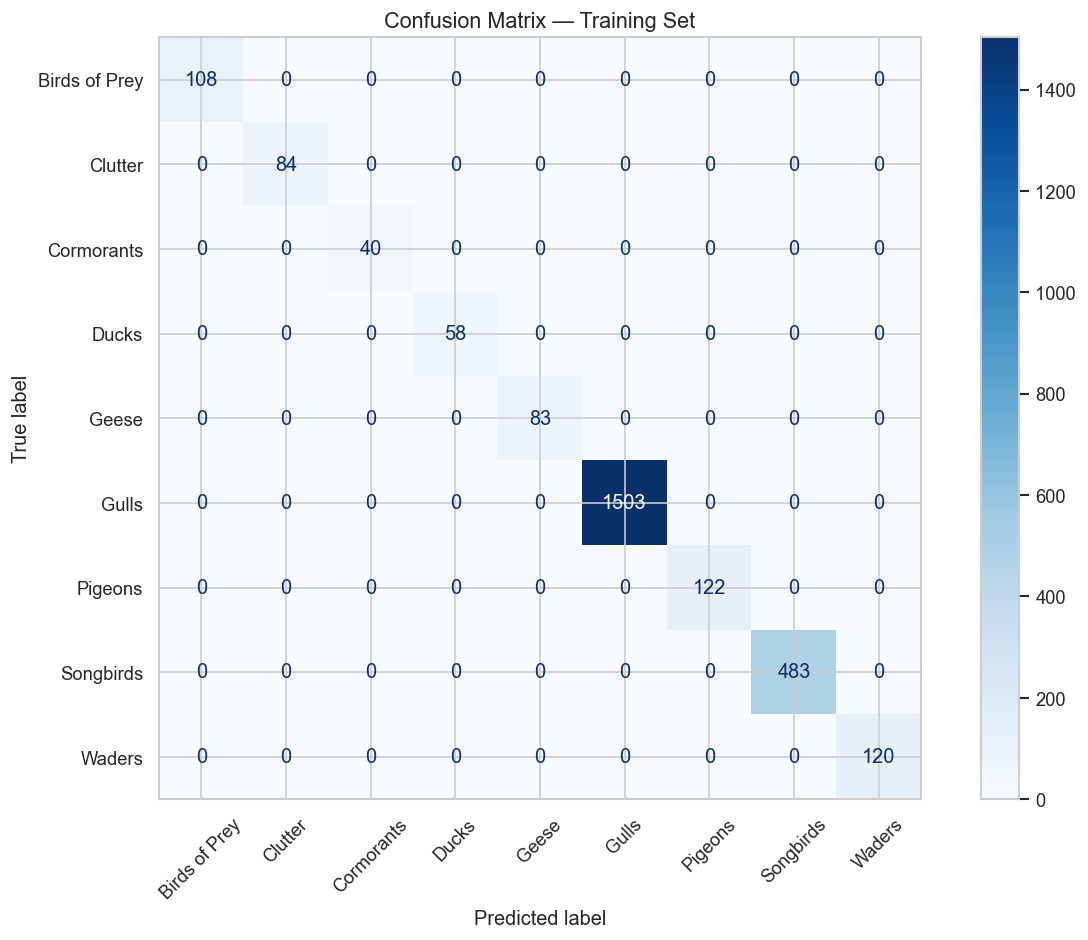


Classification Report:
               precision    recall  f1-score   support

Birds of Prey       1.00      1.00      1.00       108
      Clutter       1.00      1.00      1.00        84
   Cormorants       1.00      1.00      1.00        40
        Ducks       1.00      1.00      1.00        58
        Geese       1.00      1.00      1.00        83
        Gulls       1.00      1.00      1.00      1503
      Pigeons       1.00      1.00      1.00       122
    Songbirds       1.00      1.00      1.00       483
       Waders       1.00      1.00      1.00       120

     accuracy                           1.00      2601
    macro avg       1.00      1.00      1.00      2601
 weighted avg       1.00      1.00      1.00      2601



In [19]:
y_pred_train = model.predict(X_train)
le = LabelEncoder().fit(y_train)
cm = confusion_matrix(y_train, y_pred_train, labels=model.classes_)

fig, ax = plt.subplots(figsize=(11, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Training Set', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_train.png', bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_train, y_pred_train))

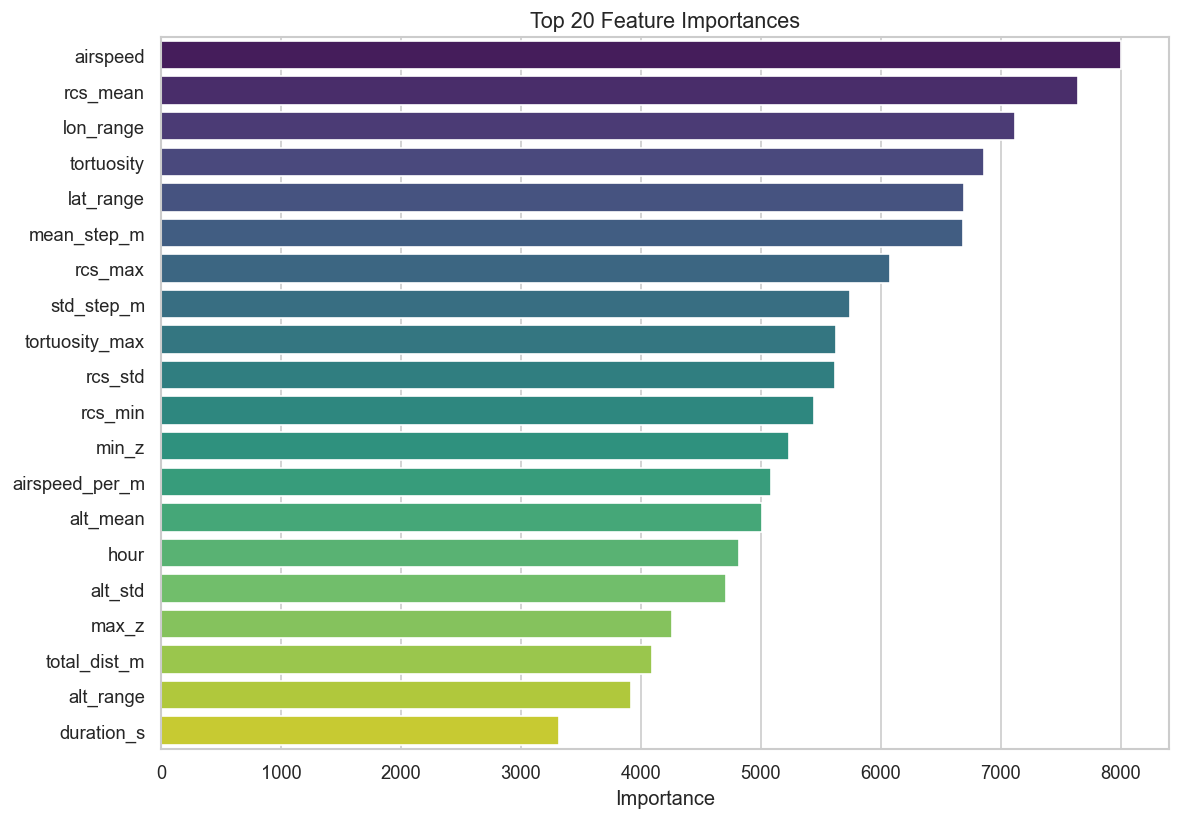

In [20]:
feat_names = X_train_raw.columns.tolist()

if HAS_LGB:
    importances = model.feature_importances_
else:
    importances = model.feature_importances_

imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Top 20 Feature Importances', fontsize=13)
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

Generate submission

In [21]:
# Predict probabilities for the test set
proba = model.predict_proba(X_test)  # shape: (n_test, n_classes)
pred_classes = model.classes_

# Build submission DataFrame with the exact expected columns
submission = pd.DataFrame(index=test['track_id'])
submission.index.name = 'track_id'

for col in CLASSES:
    if col in pred_classes:
        col_idx = list(pred_classes).index(col)
        submission[col] = proba[:, col_idx]
    else:
        submission[col] = 0.0

submission = submission.reset_index()
submission.to_csv('submission.csv', index=False)
print(f'Saved submission.csv  shape: {submission.shape}')
submission.head()

Saved submission.csv  shape: (1872, 10)


,track_id,Clutter,Cormorants,Pigeons,Ducks,Geese,Gulls,Birds of Prey,Waders,Songbirds
0,6868504,1.913170e-05,0.000039,4.155279e-05,3.963796e-04,0.987890,0.011489,1.789325e-06,0.000082,3.996919e-05
1,6868536,3.083662e-04,0.006085,1.904449e-03,1.864628e-03,0.173783,0.808275,6.869228e-05,0.003443,4.267495e-03
2,6868565,1.745140e-06,0.000057,6.801743e-06,2.582907e-04,0.999143,0.000496,8.474637e-07,0.000031,5.952397e-06
3,6868861,1.429803e-07,0.000253,5.792815e-07,1.104213e-04,0.999405,0.000025,1.938388e-07,0.000205,2.494601e-06
4,6869275,4.240118e-08,0.000204,9.880875e-08,7.625648e-07,0.999761,0.000013,5.250811e-08,0.000021,7.514465e-07


Next Steps / Ideas for Improvement

Some directions to explore after this baseline:

- **Richer trajectory features**: speed profiles, vertical climb/descent rates, sinuosity index, wingbeat proxies from RCS oscillations.
- **Sequence models**: LSTM or Transformer on the raw time-series trajectory (lon, lat, alt, rcs, Δt) — these can capture temporal patterns that summary statistics miss.
- **Species → group mapping**: if `bird_species` is available in training data, you can use it to build a hierarchical classifier or add it as a feature for the train set.
- **Observer comment NLP**: the `observer_comment` column may encode useful expert knowledge — a small text classifier or keyword extraction could help.
- **Ensemble**: stack LightGBM + a sequence model for final predictions.
- **Post-processing**: apply Platt scaling or temperature scaling to calibrate the predicted probabilities.
- **Spatial context**: include distance from wind turbines or coastline as features — different species may prefer different flight corridors.
- **Class imbalance**: if Clutter dominates, consider SMOTE, focal loss, or threshold tuning per class.